# Cell type definition and basic stats - PANEL 2

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

## Parameters

In [4]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean/dataframes' ### here the resulting dataframes will be saved
MONKEY_LIST = ['L','N','F'] 
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']

AREA = 'V12'

In [5]:
### converting two word names of classes into strings on two lines
CLASS_NAMES_PLOTS = []
for name in CLASS_NAMES:
    if len(name.split()) == 2:
        CLASS_NAMES_PLOTS.append(name.replace(" ", "\n"))
    else:
        CLASS_NAMES_PLOTS.append(name)

In [6]:
CLASS_NAMES_PLOTS = ['Narrow\nBiphasic', 'Medium\nBiphasic', 'Wide', 'Narrow\nTriphasic','Medium\nTriphasic','Positive']

## Data loading

In [7]:
df_merged = load_prop_df(MONKEY_LIST,'RS',params_analysis,DF_FOLDER,exclude_noisy=True)

L
20170725
20170809
20170810
N
20240719_B1
20240719_B2
F
20240122_B1
20241216_B1


In [8]:
df_merged.shape

(3100, 110)

In [9]:
df_merged_area = df_merged[df_merged['area_merged']==AREA]
df_merged_area = df_merged_area[df_merged_area['avg_wf_zscored'].apply(lambda x: len(x) == 90)]

In [10]:
df_merged_area.shape

(2186, 110)

In [11]:
### for raitos bar plotting - we need individual animals DFs.
df_list = []
for monkey in MONKEY_LIST:
    df_aux = load_prop_df([monkey],'RS',params_analysis,DF_FOLDER,exclude_noisy=True)
    df_list.append(df_aux[df_aux['area_merged']==AREA])

L
20170725
20170809
20170810
N
20240719_B1
20240719_B2
F
20240122_B1
20241216_B1


## Functions

In [12]:
def aux_plot_FR_boxplot(df,ax,set_params):
    """
    PANEL 2
    
    Plots comparison of FR for cell classes. 
    """
    y_name = 'FR'
    x_name = 'final_class'
    colors_class = set_params['colors_class']
    alpha = set_params['box_alpha']
    font_size = set_params['box_xlabel_fontsize']
    font_rot = set_params['box_xlabel_rotation']
    sns.boxplot(data=df,ax=ax,x=x_name,y=y_name,hue=x_name, palette=colors_class, legend=False,
                    linewidth=set_params['box_line_width'],fliersize=0.7,order=set_params['cell_classes'])
    ax.set_xlabel('')
    ax.set_ylabel('FR [spike/s]',fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([-5,150])
    #ax.set_yscale('log')
    #tick_vals = [1, 10]
    #ax.set_yticks(tick_vals)
    #ax.set_yticklabels([str(t) for t in tick_vals])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(set_params['class_names'], fontsize=font_size,rotation=font_rot)
    ax.tick_params(axis='both', labelsize=12)

   
    ### setting alpha param.
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, alpha))
    return

In [13]:
def first_peak_height_from_waveform(wf):
    # wf is a 1D numpy array (avg_wf_zscored)
    min_idx = np.argmin(wf)
    if min_idx > 0:
        max_before_idx = np.argmax(wf[:min_idx])
    else:
        max_before_idx = 0  # degenerate case
    return wf[max_before_idx]

In [14]:
def aux_plot_first_peak_heights_fig2(df,ax,set_params):
    """
    PANEL 2

    Plotting the distribution of the heights of the first peak of waveform, violinplots.
    """
    df = df[df['final_class']!='UP']
    colors_width = set_params['colors_width']
    first_peak_classif_height = set_params['first_peak_cl_height']
    #ax.axhline(first_peak_classif_height,color='gray',ls='dashed',linewidth=set_params['hline_width'])
    
    df['first_peak_height'] = [first_peak_height_from_waveform(df.loc[idx,'avg_wf_zscored']) for idx in df.index]
    order = ['narrow','medium','wide']
    sns.violinplot(data=df, x='width_wf_class', hue='width_wf_class', y='first_peak_height', 
                   palette=colors_width, inner='box', cut=0,order=order,ax=ax,legend=False,
                   linewidth=set_params['line_width'])
    ax.set_xlabel('')
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(['Narrow','Medium','Wide'],fontsize=set_params['font_size_labels'])
    ax.set_ylabel('Height [z-scored u.]',fontsize=set_params['font_size_labels'])
    ax.set_title('Height of the first peak of the waveform')

    # Set alpha for each violin 
    for violin in ax.collections:
        violin.set_alpha(0.7)  

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=14)

    return

In [15]:
def aux_plot_wf_widths_fig2(df,ax,set_params):
    """
    PANEL 2

    Histogram of the waveform widths, DOWN WFs only, final classes colorcoded.
    """
    final_classes = set_params['final_classes']
    colors_class = set_params['colors_class']
    n_bins = set_params['n_bins_widths']
    
    width_data = []
    color_list = []
    df_down = df[df['wf_direction']=='DOWN']
    for cl in final_classes[:-1]:  # omitting UP
        df_cl = df_down[df_down['final_class'] == cl]
        conv_30khz_to_micros = 33
        width_data.append(df_cl['width_wf'].values*conv_30khz_to_micros)
        color_list.append(colors_class[cl])
    
    # Plot all together as stacked bars
    ax.hist(width_data, bins=n_bins, stacked=True, color=color_list, alpha=0.6, 
            label=set_params['class_names'])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_ylabel('Number of cells',fontsize=set_params['font_size_labels'])
    ax.set_xlabel('WF width [micro s]',fontsize=set_params['font_size_labels'])
    ax.tick_params(axis='both', labelsize=14)
    return

In [16]:
def plot_tSNE_fig2(df_merged_area_no_UP,ax,set_params={}):
    """
    PANEL 2

    tSNE of waveforms, without including UP WFs.
    """
    tsne = TSNE(n_components=2)
    X = np.vstack(df_merged_area_no_UP['avg_wf_zscored'].values)
    X_tsne = tsne.fit_transform(X)

    labels = df_merged_area_no_UP['final_class']
    comp1 = 0
    comp2 = 1

    ax.set_title('tSNE projection of waveforms')

    sns.scatterplot(ax=ax,x=X_tsne[:, comp1], y=X_tsne[:, comp2], 
                    hue=labels, palette=CLASS_COLORS, s=20, alpha=0.3,legend=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlabel('tSNE 1 comp.',fontsize=set_params['font_size_labels'])
    ax.set_ylabel('tSNE 2 comp.',fontsize=set_params['font_size_labels'])

    # legend with unique labels only
    unique_labels = sorted(set(labels))  # Ensure unique and sorted labels
    new_labels = []
    for label in unique_labels:
        if label=='DOWN_medium_shallow':
            new_labels.append('Medium \n Shallow')
        elif label=='DOWN_medium_sharp':
            new_labels.append('Medium \n Sharp')
        elif label=='DOWN_narrow_shallow':
            new_labels.append('Narrow \n Shallow')
        elif label=='DOWN_narrow_sharp':
            new_labels.append('Narrow \n Sharp')
        elif label=='DOWN_wide':
            new_labels.append('Wide')
        else:
            print('Wrong class label name.')
        
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=CLASS_COLORS[label], label=label_name, alpha=0.6) 
                       for label, label_name in zip(unique_labels,new_labels)]
    ax.legend(handles=legend_elements,loc="center left",bbox_to_anchor=(1.0, 0.5))
    ax.tick_params(axis='both', labelsize=14)
    
    return

In [17]:
def aux_plot_number_cells_bar_fig2(df_list_animals,names_animals,ax,set_params):
    """
    Plotting number of cells in each cell class in a horizontal bar plot.
    """
    import matplotlib.patches as mpatches

    num_animals = len(names_animals)
    df_pool = pd.concat(df_list_animals)
    classes = set_params['final_classes']
    colors_class = set_params['colors_class']
    colors_ordered = [colors_class[c] for c in classes]

    # initialising dict. for the data organisation
    num_classes = {}
    ratio_classes = {}
    num_classes['pool'] = []
    ratio_classes['pool'] = []
    for name in names_animals:
        num_classes[name] = []
        ratio_classes[name] = []

    # organising the data
    for cl in classes:
        df_pool_cl = df_pool[df_pool['final_class']==cl]
        num_cl = df_pool_cl.shape[0]
        num_classes['pool'].append(num_cl)
        ratio_classes['pool'].append(num_cl/df_pool.shape[0])
        for i in range(len(names_animals)):
            df_animal = df_list_animals[i]
            df_animal_cl = df_animal[df_animal['final_class']==cl]
            name_animal = names_animals[i]
            num_cl_animal = df_animal_cl.shape[0]
            num_classes[name_animal].append(num_cl_animal)
            ratio_classes[name_animal].append(num_cl_animal/df_animal.shape[0])

    ### PLOTTING POOL DATA BAR
    #print('Plotting the pooled data.')
    patches = []
    bottom = 0
    for idx, num, ratio in zip(range(len(num_classes['pool'])),num_classes['pool'], ratio_classes['pool']):
        ax.bar(x=num_animals+0.4,width=0.8,height=num,color=colors_ordered[idx],bottom=bottom,alpha=set_params['bars_alpha_pool'])
        ax.text(x=num_animals+1.4,y=bottom+num/2, s=f"{ratio*100:.1f}%", va='center',ha='center',color='black', fontsize=10)
        # legend patch
        label = set_params['class_names'][idx]  
        patch = mpatches.Patch(color=colors_ordered[idx], label=label)
        patches.append(patch)
        bottom += num

    ### PLOTTING FOR INDIVIDUAL ANIMALS
    for i in range(len(names_animals)):
        bottom = 0
        name_animal = names_animals[i]
        for idx, num, ratio in zip(range(len(num_classes[name_animal])),num_classes[name_animal], ratio_classes[name_animal]):
            ax.bar(x=i,width=0.8,height=num,color=colors_ordered[idx],bottom=bottom,alpha=set_params['bars_alpha_indiv'])
            bottom += num

    ax.set_title('Number of cells in the population')
    ax.set_xlim([-0.5,num_animals + 0.8])
    ax.set_xticks(list(range(num_animals))+[num_animals+0.3])
    ax.set_xticklabels(names_animals+['All'],fontsize=12)
    ax.tick_params(axis='x', which='both', length=0) # making X ticks invisible
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylabel('Num. cells',fontsize=14)
    ax.legend(handles=patches, loc='upper left', fontsize=9, title_fontsize=5,ncol=2)
    
    for pos in ['top','bottom','right']:
        ax.spines[pos].set_visible(False)
    return

In [18]:
def plot_cl_waveforms_fig2(df,cell_cl,ax,set_params,buffer=45):
    """
    Plotting all average waveform of 'cell_cl' out of the given df.
    """
    df_cl = df[df['final_class']==cell_cl]

    list_wf_cl = []
    for idx in df_cl.index:
        avg_wf = df_cl.loc[idx]['avg_wf_zscored']  # Average waveform for one cell
        if cell_cl=='UP':
            idx_center = np.argmax(avg_wf)
        else:
            idx_center = np.argmin(avg_wf)
        wf_aligned = np.zeros(180)
        wf_aligned[(90-idx_center):(90-idx_center+90)] = avg_wf
        ax.plot(range(2*buffer),wf_aligned[90-buffer:90+buffer],alpha=0.03,color='gray')
        list_wf_cl.append(wf_aligned)

    #total_avg_wf = np.mean(np.vstack(df_cl['avg_wf_zscored'].values),axis=0)
    total_avg_wf = np.mean(np.vstack(list_wf_cl),axis=0)
    ax.plot(range(2*buffer),total_avg_wf[90-buffer:90+buffer],color=set_params['colors_class'][cl],linewidth=1.5)

    #ax.set_ylabel('Amplitude \n [z-scored u.]')
    #ax.set_xlabel('Time \n [micro s.]')
    ax.set_xticks(np.arange(0,2*buffer+1,buffer))
    ax.set_xticklabels(np.arange(0,2*buffer+1,buffer)*33)  # conversion to micro s
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return 

## Plotting

Neighbouring graph calculation is in the separate jupyter notebook.

In [19]:
set_params={}
set_params['final_classes'] = FINAL_CLASSES
set_params['colors_class'] = params_analysis['colors_class']
set_params['colors_width'] = params_analysis['colors_width']
set_params['class_names'] = CLASS_NAMES_PLOTS
set_params['first_peak_cl_height'] = 2 #params_analysis['first_peak_height']
set_params['n_bins_widths'] = 25
set_params['plot_width'] = 4.5
set_params['plot_height'] = 3
set_params['font_size_labels'] = 14
set_params['line_width'] = 2
set_params['hline_width'] = 2

### Height of the first peak distributions

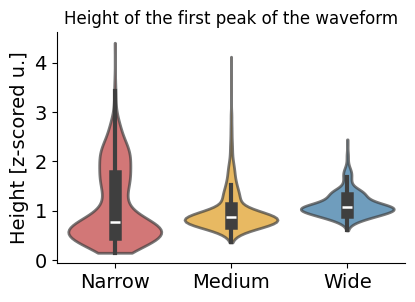

In [20]:
fig, ax = plt.subplots()
fig.set_figwidth(set_params['plot_width'])
fig.set_figheight(set_params['plot_height'])

# colors set as something in between the colors of the final classes
aux_plot_first_peak_heights_fig2(df_merged_area,ax,set_params)

plt.show()
plt.close()

### Waveform widths distributions

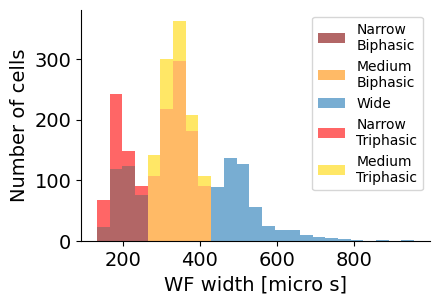

In [21]:
set_params['n_bins_widths'] = 25
fig, ax = plt.subplots()
fig.set_figwidth(set_params['plot_width'])
fig.set_figheight(set_params['plot_height'])

aux_plot_wf_widths_fig2(df_merged_area,ax,set_params)

plt.legend()
plt.show()
plt.close()

### tSNE without UP cells

In [22]:
df_merged_area_no_UP = df_merged_area[df_merged_area['final_class']!='UP']

In [23]:
set_params['plot_width'] = 4
set_params['plot_height'] = 3
set_params['font_size_labels'] = 15

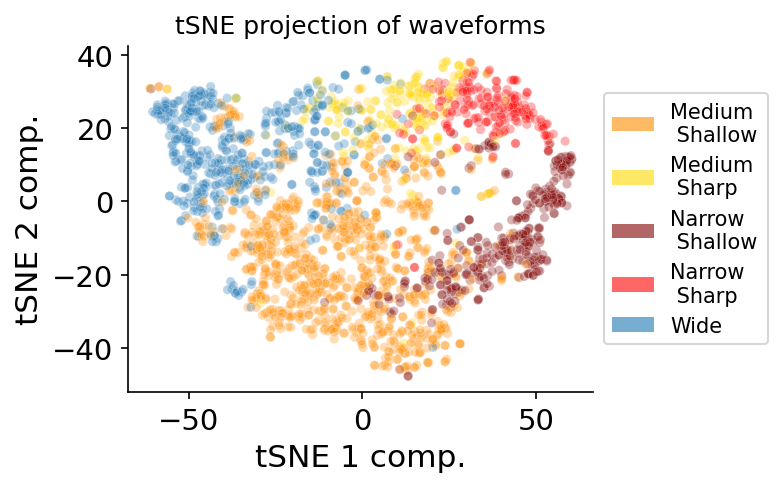

In [24]:
fig, ax = plt.subplots(dpi=150)
fig.set_figwidth(set_params['plot_width'])
fig.set_figheight(set_params['plot_height'])

plot_tSNE_fig2(df_merged_area_no_UP,ax,set_params=set_params)

plt.show()
plt.close()

### Barplot of number of cells in the population

In [25]:
set_params['plot_width'] = 3.5
set_params['plot_height'] = 3.5

In [26]:
set_params['bars_alpha_pool'] = 0.8
set_params['bars_alpha_indiv'] = 0.6

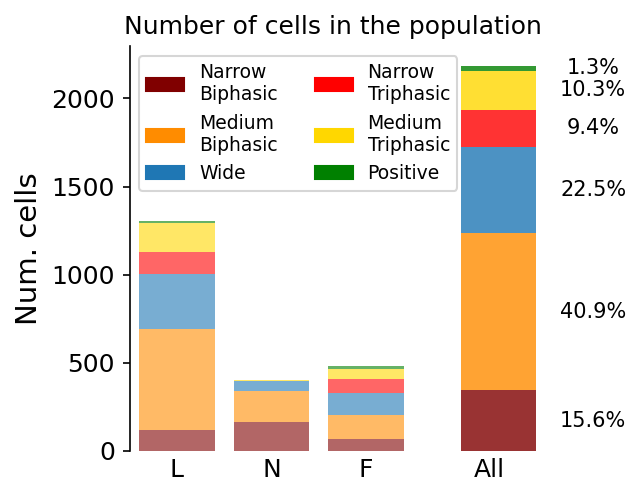

In [27]:
fig, ax = plt.subplots(dpi=150)
fig.set_figwidth(set_params['plot_width'])
fig.set_figheight(set_params['plot_height'])

aux_plot_number_cells_bar_fig2(df_list,MONKEY_LIST,ax,set_params)

plt.show()
plt.close()

In [28]:
np.sum([len(df_aux) for df_aux in df_list])

np.int64(2186)

### Example waveforms

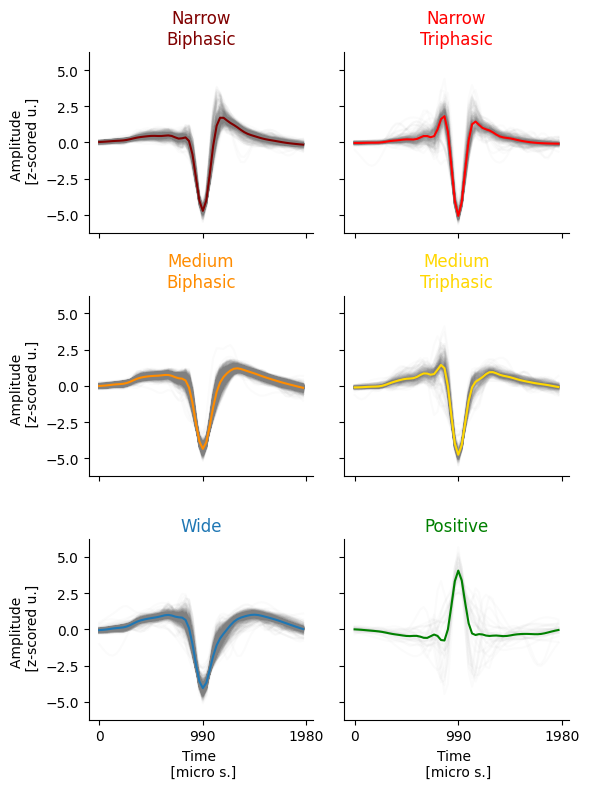

In [29]:
fig, ax = plt.subplots(3,2,sharey=True,sharex=True)
fig.set_figwidth(6)
fig.set_figheight(8)

for i,cl in enumerate(set_params['final_classes']):
    col = i//3
    row = i%3
    plot_cl_waveforms_fig2(df_merged_area,cl,ax[row,col],set_params,buffer=30)
    ax[row,col].set_title(set_params['class_names'][i],color=set_params['colors_class'][cl])

ax[2,0].set_xlabel('Time \n [micro s.]')
ax[2,1].set_xlabel('Time \n [micro s.]')
ax[0,0].set_ylabel('Amplitude \n [z-scored u.]')
ax[1,0].set_ylabel('Amplitude \n [z-scored u.]')
ax[2,0].set_ylabel('Amplitude \n [z-scored u.]')

plt.tight_layout()
plt.show()
plt.close()

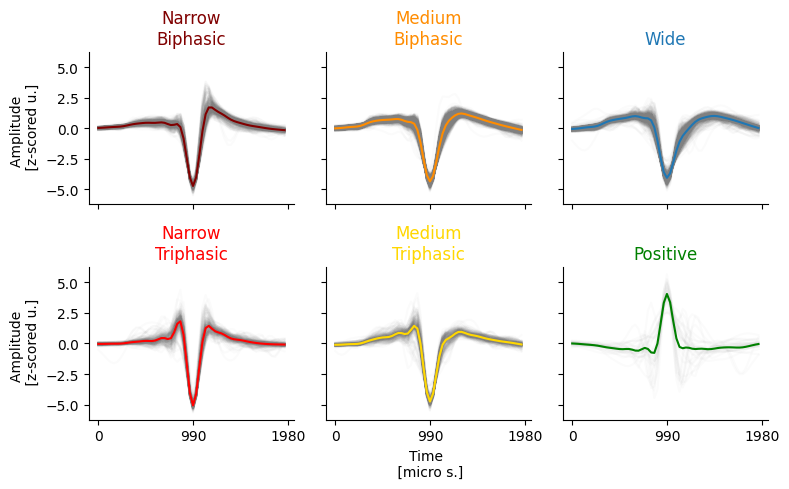

In [30]:
fig, ax = plt.subplots(2,3,sharey=True,sharex=True)
fig.set_figwidth(8)
fig.set_figheight(5)

for i,cl in enumerate(set_params['final_classes']):
    row = i//3
    col = i%3
    plot_cl_waveforms_fig2(df_merged_area,cl,ax[row,col],set_params,buffer=30)
    ax[row,col].set_title(set_params['class_names'][i],color=set_params['colors_class'][cl])

ax[1,1].set_xlabel('Time \n [micro s.]')
ax[0,0].set_ylabel('Amplitude \n [z-scored u.]')
ax[1,0].set_ylabel('Amplitude \n [z-scored u.]')

plt.tight_layout()
plt.show()
plt.close()

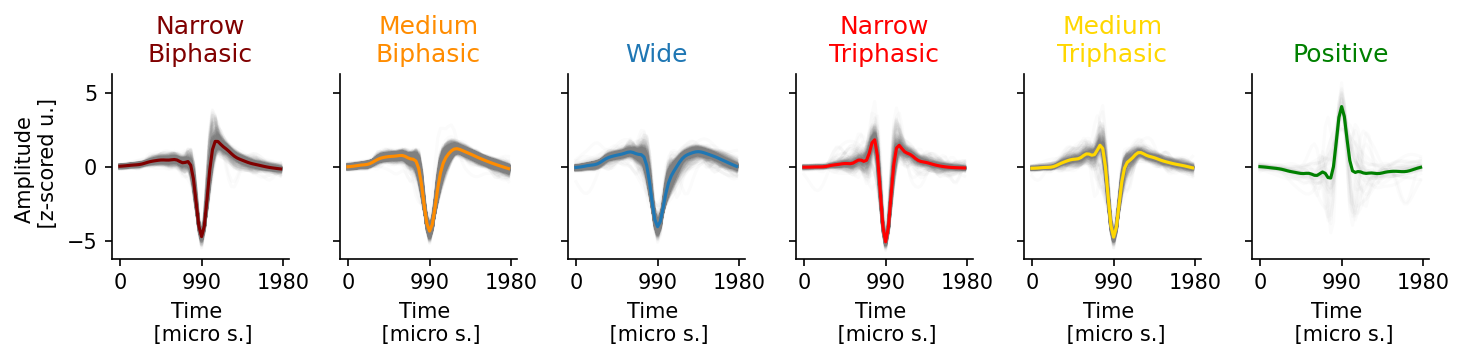

In [31]:
fig, ax = plt.subplots(1,6,sharey=True,sharex=True,dpi=150)
fig.set_figwidth(10)
fig.set_figheight(2.5)

for i,cl in enumerate(set_params['final_classes']):
    plot_cl_waveforms_fig2(df_merged_area,cl,ax[i],set_params,buffer=30)
    ax[i].set_title(set_params['class_names'][i],color=set_params['colors_class'][cl])
    ax[i].set_xlabel('Time \n [micro s.]')
    
ax[0].set_ylabel('Amplitude \n [z-scored u.]')

plt.tight_layout()
plt.show()
plt.close()

## Firing rate

In [32]:
set_params['box_alpha'] = 0.8
set_params['box_xlabel_fontsize'] = 12
set_params['box_xlabel_rotation'] = 90
set_params['box_hline_width'] = 2
set_params['box_line_width'] = 1.7
set_params['cell_classes'] = FINAL_CLASSES

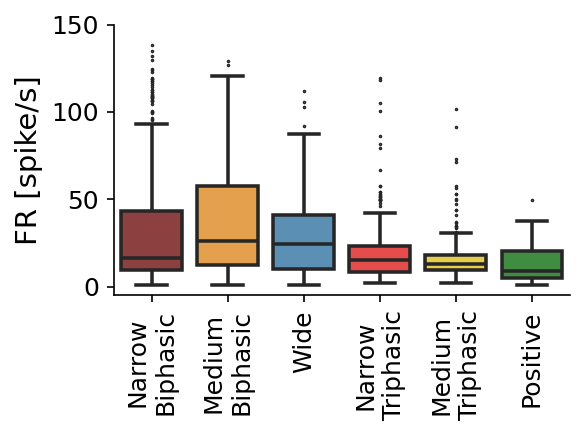

In [33]:
fig, ax = plt.subplots(dpi=150)
fig.set_figwidth(4)
fig.set_figheight(3)

aux_plot_FR_boxplot(df_merged_area,ax,set_params)

plt.tight_layout()
plt.show()
plt.close()